In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import sys
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
def summary(dataset, target):
    print("Dimensions: ", dataset.shape)
    print("Datatypes: ", dataset.dtypes.unique())
    print("Missing values:", dataset.isna().sum().sum())
    print("Missing values total:", dataset.isna().sum().sum())

    if dataset[target].isna().sum() > 0:
        dataset = dataset.dropna(subset=[target]).reset_index(drop=True)
        print("Target had missing values. These rows were removed.")
        print("Dimensions: ", dataset.shape)

    print("Target_table:")
    print(dataset[target].value_counts(dropna=False))
    print(dataset[target].value_counts(normalize=True, dropna=False))

In [4]:
na_values = ["NA", "", "NULL", "unknown", "Unknown", "na"]

# DIABETES #

In [5]:
diabetes = pd.read_csv("datasets/diabetes.csv", na_values=na_values)

In [6]:
print("---------------------------------------")
print("Dataset preview")
print("---------------------------------------")
print(diabetes.head())
print("---------------------------------------")
print("Columns types")
print("---------------------------------------")
print(diabetes.dtypes)
print("---------------------------------------")
print("Summary")
print("---------------------------------------")
summary(diabetes, "Outcome")

---------------------------------------
Dataset preview
---------------------------------------
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
---------------------------------------
Columns types
---------------------------------------
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinT

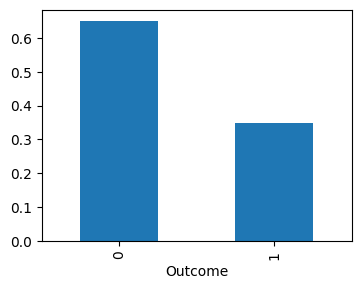

In [7]:
plt.figure(figsize=(4, 3))
diabetes['Outcome'].value_counts(normalize=True).plot(kind="bar")
plt.show()

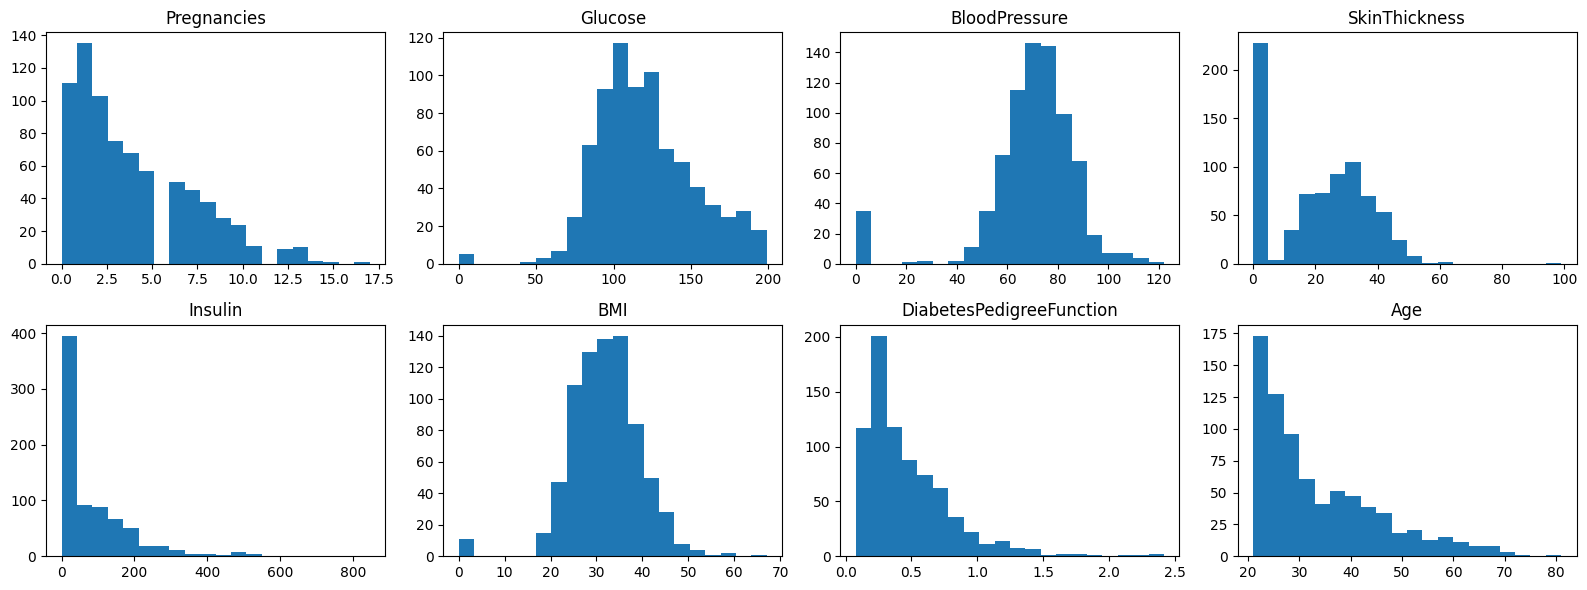

In [8]:
numeric_vars = diabetes.columns[:-1]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for ax, col in zip(axes, numeric_vars):
    ax.hist(diabetes[col], bins=20)
    ax.set_title(col)
for ax in axes[len(numeric_vars):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

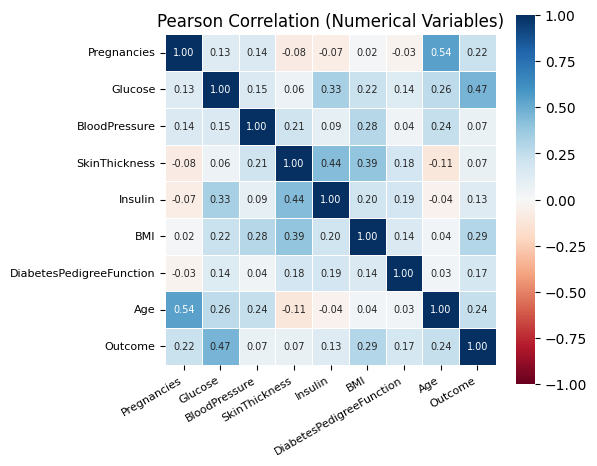

In [9]:
corr = diabetes.corr()

plt.figure(figsize=(6, 5))
cmap = plt.get_cmap("RdBu")   
sns.heatmap(
    corr,
    cmap=cmap,
    vmin=-1, vmax=1,
    center=0,                 # ensures white at 0
    square=True,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.5,
    cbar_kws={"orientation": "vertical"}
)
plt.title("Pearson Correlation (Numerical Variables)")
plt.xticks(rotation=30, ha="right", fontsize=8, color="black")
plt.yticks(rotation=0, fontsize=8, color="black")

plt.tight_layout()
plt.show()

In [10]:
diabetes_train, diabetes_test = train_test_split(diabetes, test_size=0.2, random_state=42)
print(diabetes_train.shape)
print(diabetes_test.shape)

(614, 9)
(154, 9)


While no values are marked as NA, we treat the number 0 as missing variable in all columns except Pregnancy, DiabetesPedigreeFunction and Outcome. For all other variables 0 is an impossible value.

In [11]:
rep_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Age"]

# Replace impossible values with NaN
diabetes_train[rep_cols] = diabetes_train[rep_cols].replace(0, np.nan)
diabetes_test[rep_cols] = diabetes_test[rep_cols].replace(0, np.nan)

print("Missing values:", diabetes_train.isna().sum())
print("Missing values:", diabetes_test.isna().sum())

# imputer = SimpleImputer(strategy="median")
# diabetes_train[rep_cols] = imputer.fit_transform(diabetes_train[rep_cols])
imputer = KNNImputer(n_neighbors=5)
diabetes_train[rep_cols] = imputer.fit_transform(diabetes_train[rep_cols])
diabetes_test[rep_cols] = imputer.transform(diabetes_test[rep_cols])

print("Missing values:", diabetes_train.isna().sum().sum())
print("Missing values:", diabetes_test.isna().sum().sum())


Missing values: Pregnancies                   0
Glucose                       5
BloodPressure                24
SkinThickness               176
Insulin                     290
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Missing values: Pregnancies                  0
Glucose                      0
BloodPressure               11
SkinThickness               51
Insulin                     84
BMI                          4
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64
Missing values: 0
Missing values: 0


In [12]:
diabetes_train.to_csv("datasets/diabetes_train.csv", index=False)
diabetes_test.to_csv("datasets/diabetes_test.csv", index=False)

## Let's try to make the dataset more balanced by oversampling
We already have a small dataset, so undersampling might reduce it too much

In [13]:
print("----------------------------------------------------------------------------------------------")
print("Oversampling using RandomOverSampler")
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(diabetes_train.drop(['Outcome'], axis = 1), diabetes_train['Outcome'])
print(f"Original class distribution: {diabetes_train['Outcome'].value_counts()}")
print(f"Resampled class distribution: {pd.Series(y_train_resampled).value_counts()}")

diabetes_train_resampled = pd.concat(
    [X_train_resampled, y_train_resampled],
    axis=1
)
diabetes_train_resampled.to_csv("datasets/diabetes_train_balanced.csv", index=False)

----------------------------------------------------------------------------------------------
Oversampling using RandomOverSampler
Original class distribution: Outcome
0    401
1    213
Name: count, dtype: int64
Resampled class distribution: Outcome
0    401
1    401
Name: count, dtype: int64


# DRY BEANS 

In [14]:
bean = pd.read_csv("datasets/bean.csv", na_values=na_values)

In [15]:
print("---------------------------------------")
print("Dataset preview")
print("---------------------------------------")
print(bean.head())
print("---------------------------------------")
print("Columns types")
print("---------------------------------------")
print(bean.dtypes)
print("---------------------------------------")
print("Summary")
print("---------------------------------------")
summary(bean, "Class")

---------------------------------------
Dataset preview
---------------------------------------
    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272751  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness

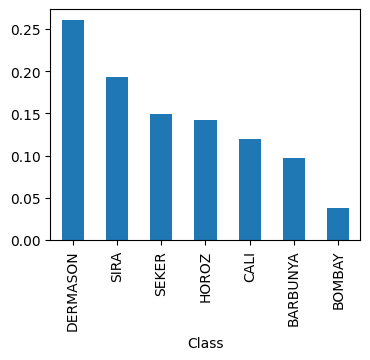

In [16]:
plt.figure(figsize=(4, 3))
bean['Class'].value_counts(normalize=True).plot(kind="bar")
plt.show()

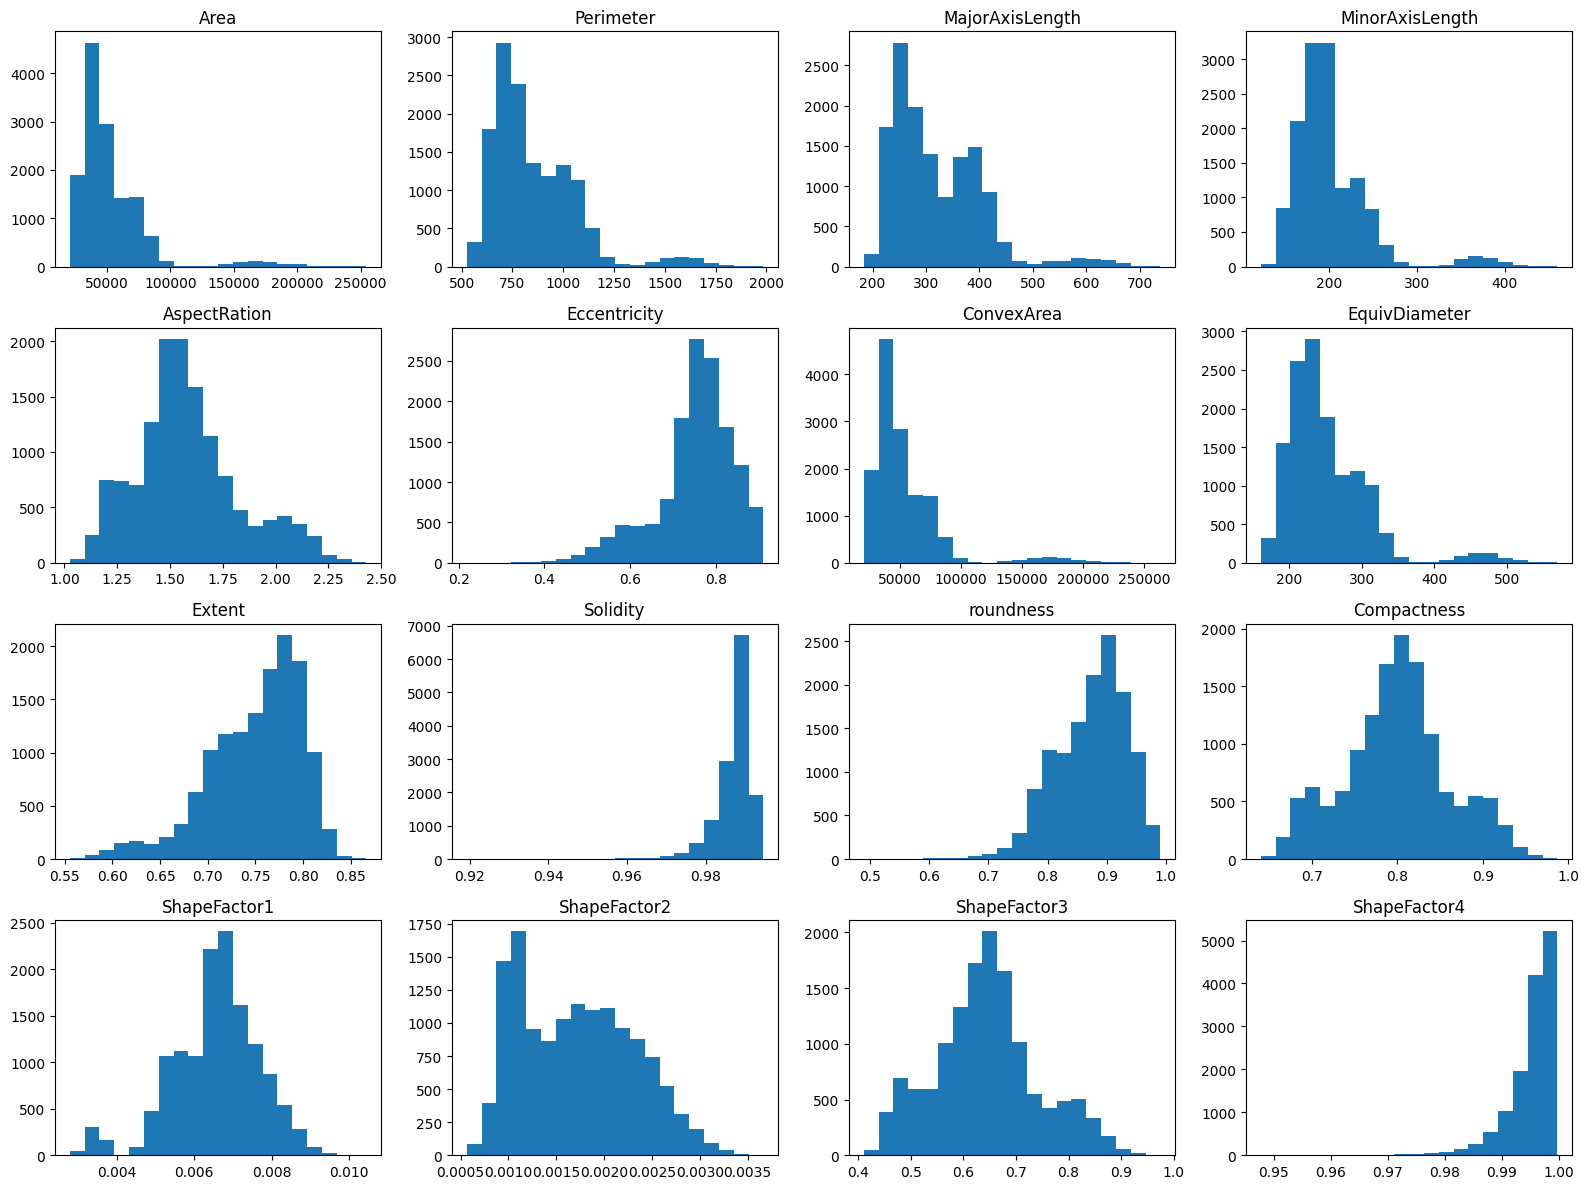

In [17]:
numeric_vars = bean.columns[:-1]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, numeric_vars):
    ax.hist(bean[col], bins=20)
    ax.set_title(col)
for ax in axes[len(numeric_vars):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

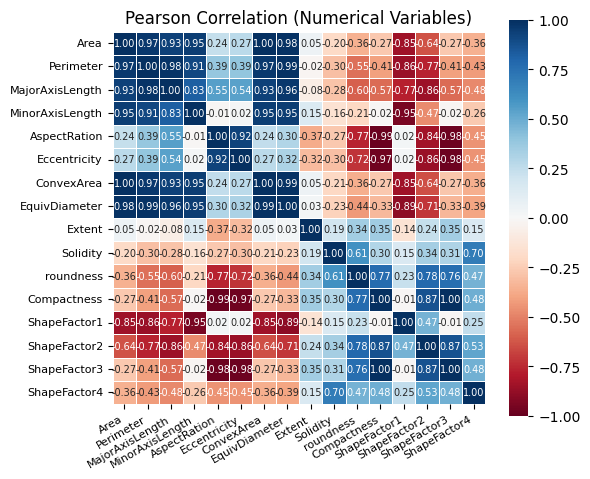

In [18]:
corr = bean.iloc[:, :-1].corr()

plt.figure(figsize=(6, 5))
cmap = plt.get_cmap("RdBu")   
sns.heatmap(
    corr,
    cmap=cmap,
    vmin=-1, vmax=1,
    center=0,                 # ensures white at 0
    square=True,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.5,
    cbar_kws={"orientation": "vertical"}
)
plt.title("Pearson Correlation (Numerical Variables)")
plt.xticks(rotation=30, ha="right", fontsize=8, color="black")
plt.yticks(rotation=0, fontsize=8, color="black")

plt.tight_layout()
plt.show()

In [19]:
bean_train, bean_test = train_test_split(bean, test_size=0.2, random_state=42)
print(bean_train.shape)
print(bean_test.shape)

(10888, 17)
(2723, 17)


In [20]:
bean_train.to_csv("datasets/bean_train.csv", index=False)
bean_test.to_csv("datasets/bean_test.csv", index=False)

In [21]:
print("----------------------------------------------------------------------------------------------")
print("Oversampling using RandomOverSampler")
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(bean_train.drop(['Class'], axis = 1), bean_train['Class'])
print(f"Original class distribution: {bean_train['Class'].value_counts()}")
print(f"Resampled class distribution: {pd.Series(y_train_resampled).value_counts()}")

bean_train_resampled = pd.concat(
    [X_train_resampled, y_train_resampled],
    axis=1
)
bean_train_resampled.to_csv("datasets/bean_train_balanced.csv", index=False)

----------------------------------------------------------------------------------------------
Oversampling using RandomOverSampler
Original class distribution: Class
DERMASON    2875
SIRA        2100
SEKER       1614
HOROZ       1520
CALI        1313
BARBUNYA    1061
BOMBAY       405
Name: count, dtype: int64
Resampled class distribution: Class
DERMASON    2875
SEKER       2875
BARBUNYA    2875
SIRA        2875
CALI        2875
HOROZ       2875
BOMBAY      2875
Name: count, dtype: int64


# CREDIT CARD

In [22]:
creditcard = pd.read_csv("datasets/credit_card.csv", na_values=na_values)

In [23]:
print("---------------------------------------")
print("Dataset preview")
print("---------------------------------------")
print(creditcard.head())
print("---------------------------------------")
print("Columns types")
print("---------------------------------------")
print(creditcard.dtypes)
print("---------------------------------------")
print("Summary")
print("---------------------------------------")
summary(creditcard, "default.payment.next.month")

---------------------------------------
Dataset preview
---------------------------------------
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  \
0     -2     -2     3913.0     3102.0      689.0        0.0        0.0   
1      0      2     2682.0     1725.0     2682.0     3272.0     3455.0   
2      0      0    29239.0    14027.0    13559.0    14331.0    14948.0   
3      0      0    46990.0    48233.0    49291.0    28314.0    28959.0   
4      0      0     8617.0     5670.0    35835.0    20940.0

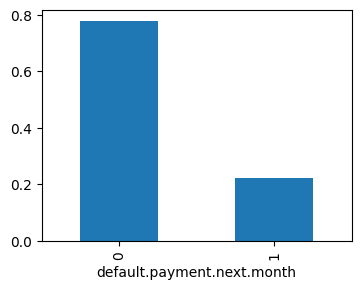

In [24]:
plt.figure(figsize=(4, 3))
creditcard['default.payment.next.month'].value_counts(normalize=True).plot(kind="bar")
plt.show()

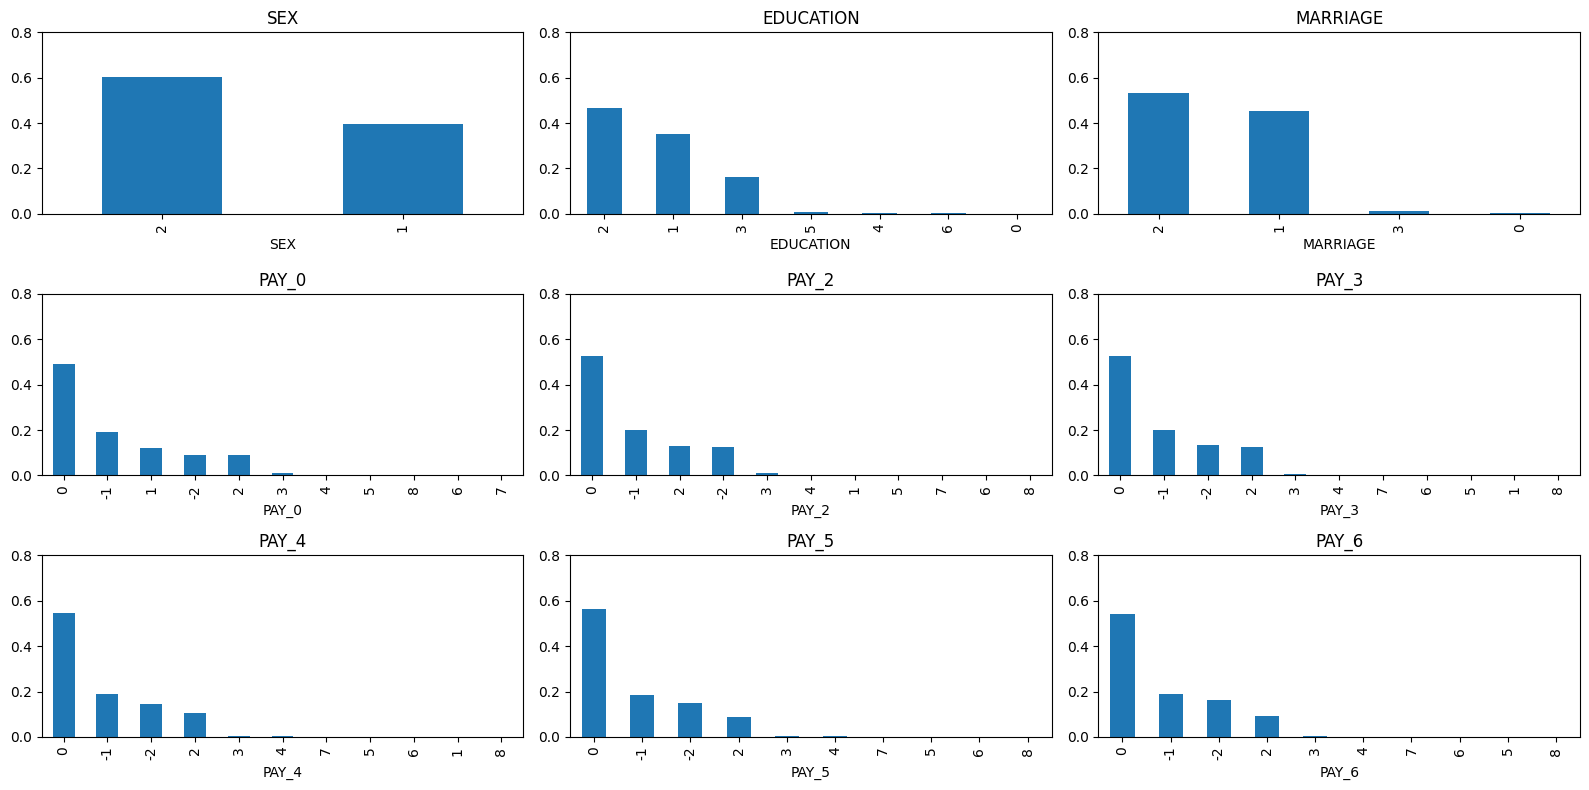

In [25]:
categorical_vars = ["SEX", "EDUCATION", "MARRIAGE",
                    "PAY_0", "PAY_2",
                    "PAY_3", "PAY_4",
                    "PAY_5", "PAY_6"]

fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, categorical_vars):
    creditcard[col].value_counts(normalize=True).plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylim(0, 0.8)

# Hide any unused subplots
for ax in axes[len(categorical_vars):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

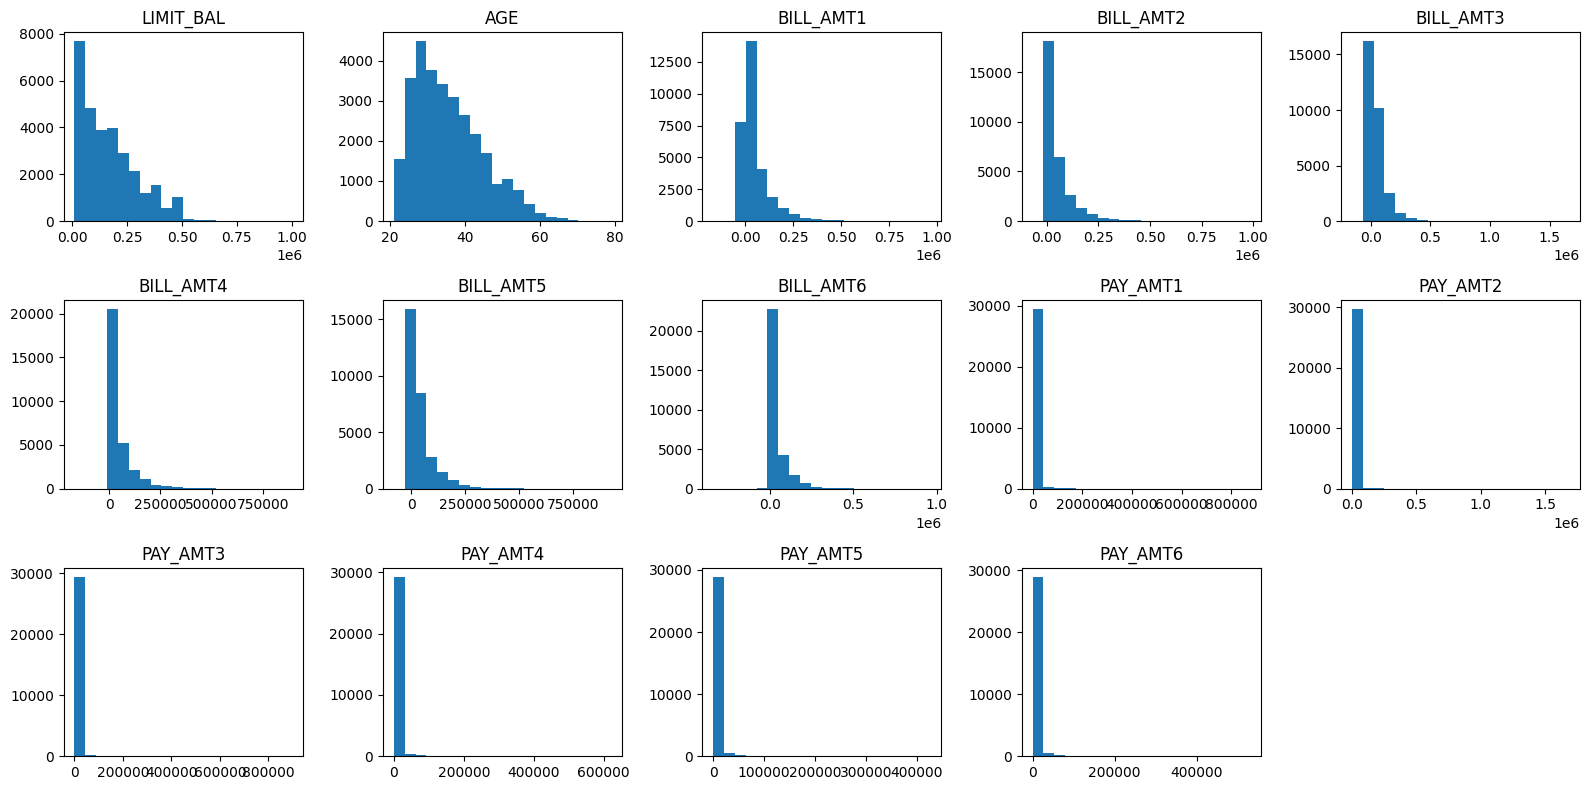

In [26]:
numeric_vars = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

fig, axes = plt.subplots(3, 5, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_vars):
    ax.hist(creditcard[col], bins=20)
    ax.set_title(col)
for ax in axes[len(numeric_vars):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

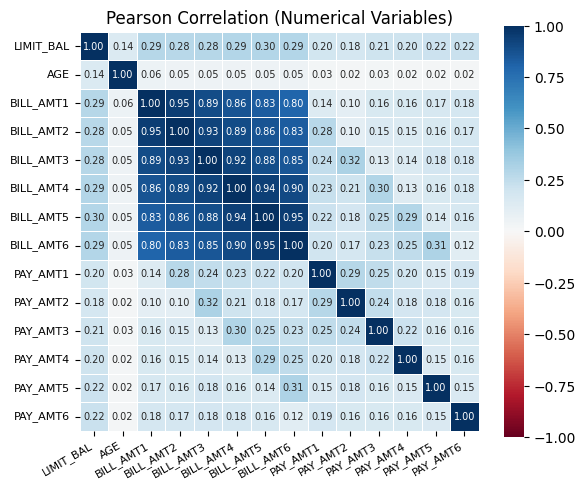

In [27]:
corr = creditcard[numeric_vars].corr()

plt.figure(figsize=(6, 5))
cmap = plt.get_cmap("RdBu")   
sns.heatmap(
    corr,
    cmap=cmap,
    vmin=-1, vmax=1,
    center=0,                 # ensures white at 0
    square=True,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.5,
    cbar_kws={"orientation": "vertical"}
)
plt.title("Pearson Correlation (Numerical Variables)")
plt.xticks(rotation=30, ha="right", fontsize=8, color="black")
plt.yticks(rotation=0, fontsize=8, color="black")

plt.tight_layout()
plt.show()

In [28]:
print(creditcard['MARRIAGE'].value_counts()) 
print(creditcard['EDUCATION'].value_counts()) 

creditcard['MARRIAGE'] = creditcard['MARRIAGE'].replace(0, 3)
creditcard['MARRIAGE'] = creditcard['MARRIAGE'].replace(0, 3)

creditcard['EDUCATION'] = creditcard['EDUCATION'].replace(0, 6)
creditcard['EDUCATION'] = creditcard['EDUCATION'].replace(0, 6)

print(creditcard['MARRIAGE'].value_counts()) 
print(creditcard['EDUCATION'].value_counts()) 

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64
MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64
EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       65
Name: count, dtype: int64


In [29]:
creditcard_train, creditcard_test = train_test_split(creditcard, test_size=0.2, random_state=42)
print(creditcard_train.shape)
print(creditcard_test.shape)

(24000, 25)
(6000, 25)


In [30]:
creditcard_train.to_csv("datasets/creditcard_train.csv", index=False)
creditcard_test.to_csv("datasets/creditcard_test.csv", index=False)

In [31]:
print("----------------------------------------------------------------------------------------------")
print("Oversampling using RandomOverSampler")
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(creditcard_train.drop(['default.payment.next.month'], axis = 1), creditcard_train['default.payment.next.month'])
print(f"Original class distribution: {creditcard_train['default.payment.next.month'].value_counts()}")
print(f"Resampled class distribution: {pd.Series(y_train_resampled).value_counts()}")

creditcard_train_resampled = pd.concat(
    [X_train_resampled, y_train_resampled],
    axis=1
)
creditcard_train_resampled.to_csv("datasets/creditcard_train_balanced.csv", index=False)

----------------------------------------------------------------------------------------------
Oversampling using RandomOverSampler
Original class distribution: default.payment.next.month
0    18677
1     5323
Name: count, dtype: int64
Resampled class distribution: default.payment.next.month
0    18677
1    18677
Name: count, dtype: int64
